# Starter Notebook: Qwen 2B LoRA for Text-to-SVG (Kaggle)

This starter is built from the resources in `contest_docs`:
- Data resources: `contest_docs/03_Data_Design.md`
- Baseline and starter guidance: `contest_docs/05_Baselines_and_Starter_Notebooks.md`
- Kaggle implementation notes: `contest_docs/06_Kaggle_Implementation_Guide.md`

Goal: provide a practical scaffold for Qwen-2B-class fine-tuning + submission generation.

## Referenced Data and Docs

### Dataset resources from `contest_docs/03_Data_Design.md`
- `OmniSVG/MMSVG-Icon`
- `xingxm/SVGX-Core-250k`
- `xingxm/SVGX-SFT-1M` (recommended subset: `SVGX_SFT_GEN_51k.json`)
- `nyuuzyou/svgfind`
- `starvector/svg-icons`
- `thesantatitan/deepseek-svg-dataset`
- `InternSVG/SArena` (evaluation benchmark)

### Qwen 2B fine-tuning references from `contest_docs/05` and `contest_docs/06`
- Unsloth Qwen fine-tune docs: https://unsloth.ai/docs/models/qwen3.5/fine-tune
- Qwen3.5-2B Vision notebook: https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Qwen3_5_(2B)_Vision.ipynb

Note: this notebook is written as a reusable starter. You may need to adjust exact model IDs and column names to match the latest upstream datasets.

In [7]:
# Uncomment in a fresh Kaggle notebook environment.
%pip install -q unsloth datasets trl transformers accelerate peft bitsandbytes pandas lxml
%pip install -q transformers==4.56.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.2/625.2 kB 12.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 78.6 MB/s eta 0:00:00:00:01
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [8]:
import os
import re
import time
import random
import xml.etree.ElementTree as ET
from datasets import Dataset
import numpy as np
import pandas as pd
import torch

from datasets import concatenate_datasets, load_dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Torch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Torch: 2.10.0+cu128
CUDA available: True


In [9]:
# Core training config.
# Keep runtime targets in line with contest_docs guidance (roughly <= 6-8 hours training).
CONFIG = {
    # "unsloth/Qwen3.5-2B"
    "model_name": "unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit",
    "max_seq_length": 2048,
    "lora_r": 32,           
    "lora_alpha": 32,      
    "learning_rate": 2e-4,
    "num_train_epochs": 1,   
    "per_device_train_batch_size": 2,
    "gradient_accumulation_steps": 8,
    "warmup_ratio": 0.05,
    "weight_decay": 0.01,
    "logging_steps": 20,
    "eval_steps": 100,
    "save_steps": 200,
    "max_train_samples_per_source": 12000,
    "eval_size": 0.02,
    "output_dir": "/kaggle/working/qwen2b_svg_lora",
    "max_new_tokens": 3000,     
    "inference_batch_size": 4,   
}

CONFIG

{'model_name': 'unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit',
 'max_seq_length': 2048,
 'lora_r': 32,
 'lora_alpha': 32,
 'learning_rate': 0.0002,
 'num_train_epochs': 1,
 'per_device_train_batch_size': 2,
 'gradient_accumulation_steps': 8,
 'warmup_ratio': 0.05,
 'weight_decay': 0.01,
 'logging_steps': 20,
 'eval_steps': 100,
 'save_steps': 200,
 'max_train_samples_per_source': 12000,
 'eval_size': 0.02,
 'output_dir': '/kaggle/working/qwen2b_svg_lora',
 'max_new_tokens': 3000,
 'inference_batch_size': 4}

In [14]:
# Data catalog using the resources listed in contest_docs/03_Data_Design.md.
DATASET_CATALOG = {
    "OmniSVG/MMSVG-Icon": {
        "split": "train",
        "prompt_fields": ["description", "keywords", "detail", "prompt", "text"],
        "svg_fields": ["svg", "picosvg", "completion", "target"],
    },
    "xingxm/SVGX-Core-250k": {
        "split": "train",
        "prompt_fields": ["qwen_caption", "blip_caption", "name", "img_analysis", "prompt"],
        "svg_fields": ["svg", "completion", "target"],
    },
    "xingxm/SVGX-SFT-1M": {
        "split": "train",
        "prompt_fields": ["prompt", "instruction", "input", "query"],
        "svg_fields": ["completion", "output", "svg", "response"],
    },
    "thesantatitan/deepseek-svg-dataset": {
        "split": "train",
        "prompt_fields": ["prompt", "instruction", "input"],
        "svg_fields": ["completion", "output", "svg"],
    },
    "competition/train_csv": {
        "split": "train",
        "file_path": "/kaggle/input/competitions/dl-spring-2026-svg-generation-from-text-prompts-extended-deadline/train.csv",
        "prompt_fields": ["prompt"], 
        "svg_fields": ["svg"],         
    },
}

# For a first run, keep to 1-2 sources.
ACTIVE_SOURCES = [
    "competition/train_csv",
]

In [15]:
def _pick_first_non_empty(example, keys):
    for key in keys:
        if key in example and example[key] is not None:
            val = str(example[key]).strip()
            if val:
                return val
    return ""


def to_prompt_svg(example, prompt_fields, svg_fields):
    prompt = _pick_first_non_empty(example, prompt_fields)
    svg = _pick_first_non_empty(example, svg_fields)
    if not svg.lower().startswith("<svg"):
        return {"prompt": "", "svg": ""}
    return {"prompt": prompt, "svg": svg}


def load_source_dataset(dataset_id, cfg, max_samples):
    print(f"Loading {dataset_id} ...")


    if "file_path" in cfg:
        df = pd.read_csv(cfg["file_path"])
        if max_samples and len(df) > max_samples:
            df = df.sample(max_samples, random_state=SEED)
        ds = Dataset.from_pandas(df, preserve_index=False)

    else:
        ds = load_dataset(dataset_id, split=cfg["split"])
        if max_samples and len(ds) > max_samples:
            ds = ds.shuffle(seed=SEED).select(range(max_samples))
    
    
    ds = ds.map(
        lambda ex: to_prompt_svg(ex, cfg["prompt_fields"], cfg["svg_fields"]),
        remove_columns=ds.column_names,
        desc=f"normalizing {dataset_id}",
    )
    ds = ds.filter(lambda x: bool(x["prompt"]) and bool(x["svg"]))
    print(f"{dataset_id}: {len(ds)} usable rows")
    return ds

In [16]:
datasets_ok = []
for source in ACTIVE_SOURCES:
    try:
        ds = load_source_dataset(
            source,
            DATASET_CATALOG[source],
            CONFIG["max_train_samples_per_source"],
        )
        datasets_ok.append(ds)
    except Exception as e:
        print(f"Skipping {source}: {type(e).__name__}: {e}")

if not datasets_ok:
    raise RuntimeError("No dataset loaded. Check dataset IDs, internet access, and schema fields.")

train_raw = datasets_ok[0] if len(datasets_ok) == 1 else concatenate_datasets(datasets_ok)
train_raw = train_raw.shuffle(seed=SEED)

splits = train_raw.train_test_split(test_size=CONFIG["eval_size"], seed=SEED)
train_ds = splits["train"]
eval_ds = splits["test"]

print(f"Train rows: {len(train_ds)}")
print(f"Eval rows: {len(eval_ds)}")
train_ds[0]

Loading competition/train_csv ...


normalizing competition/train_csv:   0%|          | 0/12000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/12000 [00:00<?, ? examples/s]

competition/train_csv: 12000 usable rows
Train rows: 11760
Eval rows: 240


{'prompt': 'The image features a blue geometric shape resembling a box or container, surrounded by small blue and teal dots, with a teal vertical line extending from one side of the shape.',
 'svg': '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 200.0 200.0" height="200.0px" width="200.0px"><path fill="#4D73B6" fill-opacity="1.0"  filling="0" d="M12.462890625 45.18359375 A5.47265625 5.47265625 0.0 1 0 23.408203125 45.18359375 A5.47265625 5.47265625 0.0 1 0 12.462890625 45.18359375 Z"></path>\n<path fill="#44BDDC" fill-opacity="1.0"  filling="0" d="M22.0390625 24.57421875 A5.47265625 5.47265625 0.0 1 0 32.984375 24.57421875 A5.47265625 5.47265625 0.0 1 0 22.0390625 24.57421875 Z"></path>\n<path fill="#4D73B6" fill-opacity="1.0"  filling="0" d="M151.66015625 35.51953125 A5.47265625 5.47265625 0.0 1 0 162.60546875 35.51953125 A5.47265625 5.47265625 0.0 1 0 151.66015625 35.51953125 Z"></path>\n<path fill="#44BDDC" fill-opacity="1.0"  filling="0" d="M176.71484375 96.220703125 L17

In [17]:
SYSTEM_PROMPT = (
    "You generate compact, valid SVG markup from user requests. "
    "Return ONLY SVG code — no explanation, no markdown fences. "
    "Use a single root <svg> element with "
    'width="256" height="256" viewBox="0 0 256 256". '
    "Allowed tags: svg, g, path, rect, circle, ellipse, line, polyline, polygon, "
    "defs, use, symbol, clipPath, mask, linearGradient, radialGradient, stop, "
    "text, tspan, title, desc, style, pattern, marker, filter. "
    "No scripts, no animation, no external references."
)


def format_sft_text(example):
    text = (
        "<|im_start|>system\n"
        f"{SYSTEM_PROMPT}<|im_end|>\n"
        "<|im_start|>user\n"
        f"{example['prompt']}<|im_end|>\n"
        "<|im_start|>assistant\n"
        f"{example['svg']}<|im_end|>"
    )
    return {"text": text}


train_text = train_ds.map(format_sft_text, remove_columns=train_ds.column_names)
eval_text = eval_ds.map(format_sft_text, remove_columns=eval_ds.column_names)

print(train_text[0]["text"][:400])

Map:   0%|          | 0/11760 [00:00<?, ? examples/s]

Map:   0%|          | 0/240 [00:00<?, ? examples/s]

<|im_start|>system
You generate compact, valid SVG markup from user requests. Return ONLY SVG code — no explanation, no markdown fences. Use a single root <svg> element with width="256" height="256" viewBox="0 0 256 256". Allowed tags: svg, g, path, rect, circle, ellipse, line, polyline, polygon, defs, use, symbol, clipPath, mask, linearGradient, radialGradient, stop, text, tspan, title, desc, sty


In [18]:
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=CONFIG["model_name"],
    max_seq_length=CONFIG["max_seq_length"],
    dtype=None,
    load_in_4bit=True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=CONFIG["lora_r"],
    lora_alpha=CONFIG["lora_alpha"],
    lora_dropout=0,
    bias="none",
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    use_gradient_checkpointing="unsloth",
    random_state=SEED,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


2026-03-31 18:58:39.768524: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774983519.982100      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774983520.042839      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774983520.563424      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774983520.563449      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774983520.563452      55 computation_placer.cc:177] computation placer alr

🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.3.18: Fast Qwen2 patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.14G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

unsloth/qwen2.5-1.5b-instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.3.18 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


In [19]:
from transformers import TrainingArguments
from trl import SFTTrainer, SFTConfig

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_text,
    eval_dataset=eval_text,
    args=SFTConfig(
        output_dir=CONFIG["output_dir"],
        num_train_epochs=CONFIG["num_train_epochs"],
        per_device_train_batch_size=CONFIG["per_device_train_batch_size"],
        gradient_accumulation_steps=CONFIG["gradient_accumulation_steps"],
        learning_rate=CONFIG["learning_rate"],
        warmup_ratio=CONFIG["warmup_ratio"],
        weight_decay=CONFIG["weight_decay"],
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        logging_steps=CONFIG["logging_steps"],
        eval_strategy="steps",
        eval_steps=CONFIG["eval_steps"],
        save_steps=CONFIG["save_steps"],
        save_total_limit=2,
        report_to="none",
        optim="paged_adamw_8bit",
        lr_scheduler_type="cosine",
        seed=SEED,
        dataset_text_field="text",
        max_seq_length=CONFIG["max_seq_length"],
        packing=True,
    ),
)

train_result = trainer.train()
print(train_result)

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/11760 [00:00<?, ? examples/s]

Unsloth: Packing train dataset (num_proc=8):   0%|          | 0/11760 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/240 [00:00<?, ? examples/s]

Unsloth: Packing eval dataset (num_proc=8):   0%|          | 0/240 [00:00<?, ? examples/s]

🦥 Unsloth: Packing enabled - training is >2x faster and uses less VRAM!


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 9,261 | Num Epochs = 1 | Total steps = 579
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 8 x 1) = 16
 "-____-"     Trainable parameters = 36,929,536 of 1,580,643,840 (2.34% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
100,0.446900,0.401608
200,0.399600,0.354576
300,0.371900,0.333583
400,0.334800,0.322718
500,0.333000,0.316356


Unsloth: Not an error, but Qwen2ForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


TrainOutput(global_step=579, training_loss=0.39704941962049417, metrics={'train_runtime': 15361.9912, 'train_samples_per_second': 0.603, 'train_steps_per_second': 0.038, 'total_flos': 1.5140594393961062e+17, 'train_loss': 0.39704941962049417, 'epoch': 1.0})


In [20]:
os.makedirs(CONFIG["output_dir"], exist_ok=True)
trainer.save_model(CONFIG["output_dir"])
tokenizer.save_pretrained(CONFIG["output_dir"])

print(f"Saved adapter + tokenizer to: {CONFIG['output_dir']}")

Saved adapter + tokenizer to: /kaggle/working/qwen2b_svg_lora


In [21]:
FastLanguageModel.for_inference(model)

SVG_REGEX = re.compile(r"<svg[\s\S]*?(?:</svg>|$)", flags=re.IGNORECASE)

# def extract_svg(text):
#     m = SVG_REGEX.search(text)
#     return m.group(0).strip() if m else ""

import re

def round_floats(svg_text):
    """Round all floats to 2 decimal places to reduce token waste."""
    return re.sub(r'(\d+\.\d{3,})', lambda m: str(round(float(m.group()), 2)), svg_text)

def extract_svg(text):
    # Find the last <svg tag (the generated one, not system prompt)
    start = text.rfind("<svg")
    
    # If no <svg found after "assistant", look for content after assistant marker
    assistant_split = text.split("assistant\n")
    if len(assistant_split) > 1:
        response = assistant_split[-1].strip()
        if response:
            # Wrap in svg tag if missing
            if not response.startswith("<svg"):
                response = f'<svg xmlns="http://www.w3.org/2000/svg" width="256" height="256" viewBox="0 0 256 256">{response}</svg>'
            else:
                end = response.find("</svg>")
                if end != -1:
                    response = response[:end + 6]
                else:
                    response = response.rsplit("<path", 1)[0] + "</svg>"
            return round_floats(response).strip()
    
    if start == -1:
        return ""
    svg_part = text[start:]
    end = svg_part.find("</svg>")
    if end != -1:
        svg_part = svg_part[:end + 6]
    else:
        svg_part = svg_part.rsplit("<path", 1)[0] + "</svg>"
    return round_floats(svg_part).strip()

def is_valid_svg(svg_text):
    if not svg_text:
        print("Empty SVG")
        return False
    try:
        root = ET.fromstring(svg_text)
        return root.tag.endswith("svg")
    except ET.ParseError as e:
        print(f"Parse error: {e}") 
        return False


def fallback_svg(_prompt):
    return (
        '<svg xmlns="http://www.w3.org/2000/svg" width="256" height="256" viewBox="0 0 256 256">'
        '<rect x="0" y="0" width="256" height="256" fill="white"/>'
        '<circle cx="128" cy="128" r="64" fill="black"/>'
        '</svg>'
    )


def generate_svg(prompt, max_new_tokens=2048):
    chat_text = (
        "<|im_start|>system\n"
        f"{SYSTEM_PROMPT}<|im_end|>\n"
        "<|im_start|>user\n"
        f"{prompt}<|im_end|>\n"
        "<|im_start|>assistant\n"
    )
    inputs = tokenizer(chat_text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=1.3,
            no_repeat_ngram_size=20,
        )
    decoded = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    print("RAW OUTPUT:", decoded)  
    svg = extract_svg(decoded)
    # print("SVG TO PARSE:", repr(svg))
    if not is_valid_svg(svg):
        print("Fallback SVG")
        svg = fallback_svg(prompt)
    
    return svg


test_prompt = "a simple blue bird icon"
pred_svg = generate_svg(test_prompt)
print(pred_svg[:500])
print("Valid SVG:", is_valid_svg(pred_svg))

RAW OUTPUT: system
You generate compact, valid SVG markup from user requests. Return ONLY SVG code — no explanation, no markdown fences. Use a single root <svg> element with width="256" height="256" viewBox="0 0 256 256". Allowed tags: svg, g, path, rect, circle, ellipse, line, polyline, polygon, defs, use, symbol, clipPath, mask, linearGradient, radialGradient, stop, text, tspan, title, desc, style, pattern, marker, filter. No scripts, no animation, no external references.
user
a simple blue bird icon
assistant
<svg fill="#4379F8" xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 100.0 100.0" height="100%" width="100%"><path d="M38.400001525878906 70.4000015258789 A6.200000076293945 6.200000076293945 0.0 0 0 32.400001525878906 64.20000457763672 L32.400001525878906 55.80000305175781 C32.400001525878906 44.0 38.39999771118164 33.20000457763672 46.900001525878906 33.20000457763672 C48.79999923706055 33.20000457763672 50.60000228881836 33.400001525878906 52.5 33.80000305175781 L52.5 34.

In [22]:
# Submission generation scaffold: expects Kaggle prompt file with columns `id,prompt`.
TEST_PROMPTS_PATH = "/kaggle/input/competitions/dl-spring-2026-svg-generation-from-text-prompts-extended-deadline/test.csv"
SUBMISSION_PATH = "/kaggle/working/submission.csv"

test_df = pd.read_csv(TEST_PROMPTS_PATH)

rows = []
invalid_count = 0
t0 = time.time()

for _, row in test_df.iterrows():
    svg = generate_svg(row["prompt"])
    if not is_valid_svg(svg):
        invalid_count += 1
        svg = fallback_svg(row["prompt"])
    rows.append({"id": row["id"], "svg": svg})

# sub_df = pd.DataFrame(rows)
# sub_df.to_csv(SUBMISSION_PATH, index=False)

# elapsed_min = (time.time() - t0) / 60
# print(f"Saved: {SUBMISSION_PATH}")
# print(f"Rows: {len(sub_df)}")
# print(f"Invalid/fallback count: {invalid_count}")
# print(f"Runtime (minutes): {elapsed_min:.2f}")
# sub_df.head()

RAW OUTPUT: system
You generate compact, valid SVG markup from user requests. Return ONLY SVG code — no explanation, no markdown fences. Use a single root <svg> element with width="256" height="256" viewBox="0 0 256 256". Allowed tags: svg, g, path, rect, circle, ellipse, line, polyline, polygon, defs, use, symbol, clipPath, mask, linearGradient, radialGradient, stop, text, tspan, title, desc, style, pattern, marker, filter. No scripts, no animation, no external references.
user
firewood stack cut logs wood with leaf illustration.
assistant
<svg enable-background="new 378419032 - 256 256/240-240 rgba(0,-1,0) none 0x' ' " version="1.1" xmlns:xlink="http://www.w3.org/TR/xpath-functions#dcterms#" x="0px" y="-64"><g fill="#eaeaea"><path d="m246 5c-.1 -.1 .1-.2-.1-.3v-1h-1l-1.5-.5a3 3 0 0 1 3-3s3 3 3 3z"/><circle cx=".10000" cy=".10000" r=".5"/></g><title><![CDATA[Firewood Stack]]></title></svg>
RAW OUTPUT: system
You generate compact, valid SVG markup from user requests. Return ONLY SVG co

In [23]:
sub_df = pd.DataFrame(rows)
sub_df.to_csv(SUBMISSION_PATH, index=False)

elapsed_min = (time.time() - t0) / 60
print(f"Saved: {SUBMISSION_PATH}")
print(f"Rows: {len(sub_df)}")
print(f"Invalid/fallback count: {invalid_count}")
print(f"Runtime (minutes): {elapsed_min:.2f}")
sub_df.head()

Saved: /kaggle/working/submission.csv
Rows: 10
Invalid/fallback count: 0
Runtime (minutes): 8.67


,id,svg
0,fa1d8fa7-080f-4269-a9cf-a17562c9a0ca,"<svg enable-background=""new 378419032 - 256 25..."
1,6eede943219547c22ac56085027d33cc,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
2,ea045c7a247166f061ce504d9b7ccaab,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
3,8fe82f3af89e487b31236ca829c3f071,"<svg xmlns=""http://www.w3.org/2000/svg"" width=..."
4,600464e4d92c75338462271a09b3f176,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."


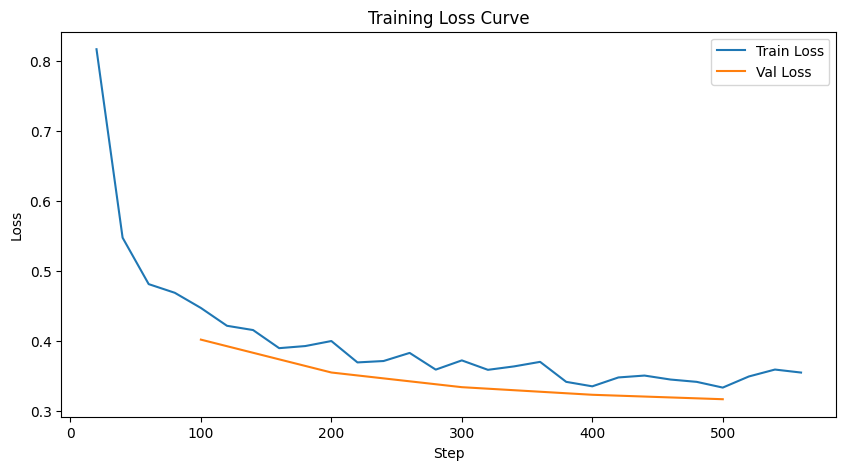

In [24]:
#validity purposes 

import matplotlib.pyplot as plt

log_history = trainer.state.log_history
train_steps = [x['step'] for x in log_history if 'loss' in x]
train_losses = [x['loss'] for x in log_history if 'loss' in x]
eval_steps = [x['step'] for x in log_history if 'eval_loss' in x]
eval_losses = [x['eval_loss'] for x in log_history if 'eval_loss' in x]

plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_losses, label='Train Loss')
plt.plot(eval_steps, eval_losses, label='Val Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.savefig('/content/loss_curve.png')
plt.show()

Valid SVGs:    10 (100.0%)
Invalid SVGs:  0 (0.0%)
Avg SVG length: 372 chars
Min SVG length: 107 chars
Max SVG length: 1058 chars


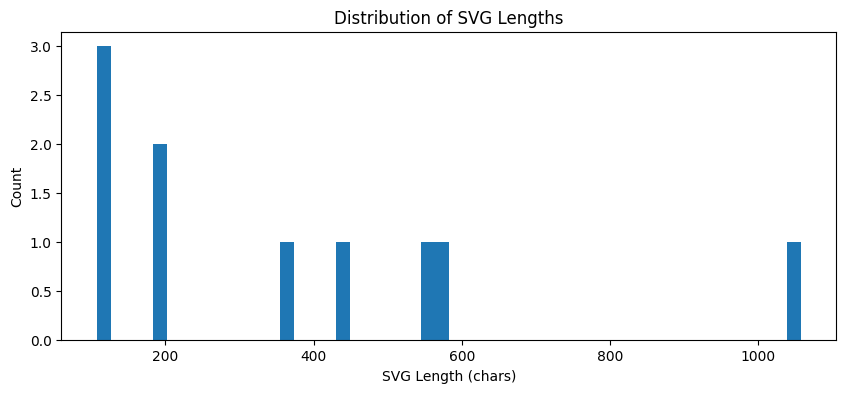

In [25]:
valid_count = 0
invalid_count = 0
fallback_count = 0
lengths = []

for _, row in sub_df.iterrows():
    svg = row['svg']
    lengths.append(len(svg))
    valid = is_valid_svg(svg)  
    if valid:
        valid_count += 1
    else:
        invalid_count += 1

print(f"Valid SVGs:    {valid_count} ({100*valid_count/len(sub_df):.1f}%)")
print(f"Invalid SVGs:  {invalid_count} ({100*invalid_count/len(sub_df):.1f}%)")
print(f"Avg SVG length: {sum(lengths)/len(lengths):.0f} chars")
print(f"Min SVG length: {min(lengths)} chars")
print(f"Max SVG length: {max(lengths)} chars")

plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=50)
plt.xlabel('SVG Length (chars)')
plt.ylabel('Count')
plt.title('Distribution of SVG Lengths')
plt.savefig('/content/svg_lengths.png')
plt.show()

Sample generated SVGs:

--- fa1d8fa7-080f-4269-a9cf-a17562c9a0ca ---



--- 6eede943219547c22ac56085027d33cc ---



--- ea045c7a247166f061ce504d9b7ccaab ---


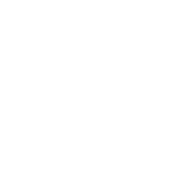


--- 8fe82f3af89e487b31236ca829c3f071 ---


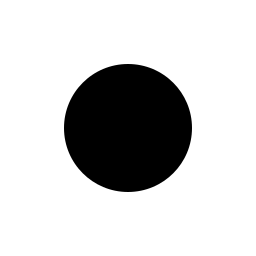


--- 600464e4d92c75338462271a09b3f176 ---


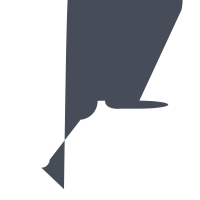

In [26]:
from IPython.display import SVG, display

print("Sample generated SVGs:")
for i in range(5):
    prompt = sub_df.iloc[i]['id']
    svg = sub_df.iloc[i]['svg']
    print(f"\n--- {prompt} ---")
    display(SVG(data=svg))

## Notes

- Keep a fixed seed, runtime logs, and invalid-generation counts (required by `contest_docs/05`).
- If you use Kaggle-packaged datasets (`svg-train-public`, `svg-test-public-prompts`, `svg-utils`), swap paths into the loading cells.
- For stricter alignment with Unsloth templates, copy the latest prompt-formatting snippets from the official Qwen3.5-2B notebook linked above.